# Aula 1 — Fundamentos e Importância da Validação de Dados em ML

**Disciplina:** Validação de Dados e Bibliotecas de Qualidade  
**Curso:** Pós-Graduação em Machine Learning — FIAP POSTECH

---

1. Data-centric AI vs. Model-centric AI — o paradigma de Andrew Ng
2. As seis dimensões de qualidade de dados (Zhou et al., 2024)
3. Data cascades e os custos de poor data quality em produção

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

---
## 1. Data-centric AI vs. Model-centric AI

**Model-centric AI** (paradigma tradicional): manter os dados fixos e iterar sobre arquiteturas, hiperparâmetros e algoritmos para melhorar o desempenho do modelo.

**Data-centric AI** (paradigma emergente, Andrew Ng, 2021): manter o modelo fixo e iterar sobre a qualidade, limpeza e curadoria dos dados. A premissa é que dados de maior qualidade geram modelos melhores de forma mais consistente.

### O estudo de referência de Andrew Ng

Em um problema de detecção de defeitos em manufatura com **apenas 500 imagens**, Ng comparou as duas abordagens:

| Abordagem | Estratégia | Ganho médio de acurácia |
|---|---|---|
| **Model-centric** | Troca de arquiteturas, ajuste de hiperparâmetros | **+0,4 pp** |
| **Data-centric** | Mesmo modelo; curadoria de rótulos e padronização | **+3,2 pp** |

O ganho da abordagem data-centric foi **8× maior** a partir do mesmo esforço. Inspirados neste experimento, vamos tentar replicar algo parecido com o dataset Breast Cancer (569 amostras).

### Experimento: qual abordagem gera mais ganho?

In [2]:
# Carrega dataset de câncer de mama (569 amostras, 30 features)
data = load_breast_cancer()
X, y = data.data, data.target

# Simula um dataset com problemas de qualidade
def introduzir_ruido(X, proporcao_ruido=0.15):
    """Adiciona ruído gaussiano em uma fração das amostras."""
    X_ruidoso = X.copy().astype(float)
    n_amostras_com_ruido = int(len(X) * proporcao_ruido)
    indices = np.random.choice(len(X), n_amostras_com_ruido, replace=False)
    X_ruidoso[indices] += np.random.normal(0, X.std(axis=0) * 3, X_ruidoso[indices].shape)
    return X_ruidoso

def introduzir_valores_ausentes(X, proporcao=0.10):
    """Substitui uma fração dos valores por NaN e imputa com a mediana."""
    X_ausente = X.copy().astype(float)
    mascara = np.random.random(X_ausente.shape) < proporcao
    X_ausente[mascara] = np.nan
    # Imputação simples pela mediana da coluna
    for col in range(X_ausente.shape[1]):
        mediana = np.nanmedian(X_ausente[:, col])
        X_ausente[np.isnan(X_ausente[:, col]), col] = mediana
    return X_ausente

# Versão com dados "sujos"
X_sujo = introduzir_ruido(X, proporcao_ruido=0.20)
X_sujo = introduzir_valores_ausentes(X_sujo, proporcao=0.10)

print(f"Dataset original: {X.shape[0]} amostras, {X.shape[1]} features")
print(f"Ruído introduzido em ~20% das amostras, valores ausentes em ~10% dos valores")

Dataset original: 569 amostras, 30 features
Ruído introduzido em ~20% das amostras, valores ausentes em ~10% dos valores


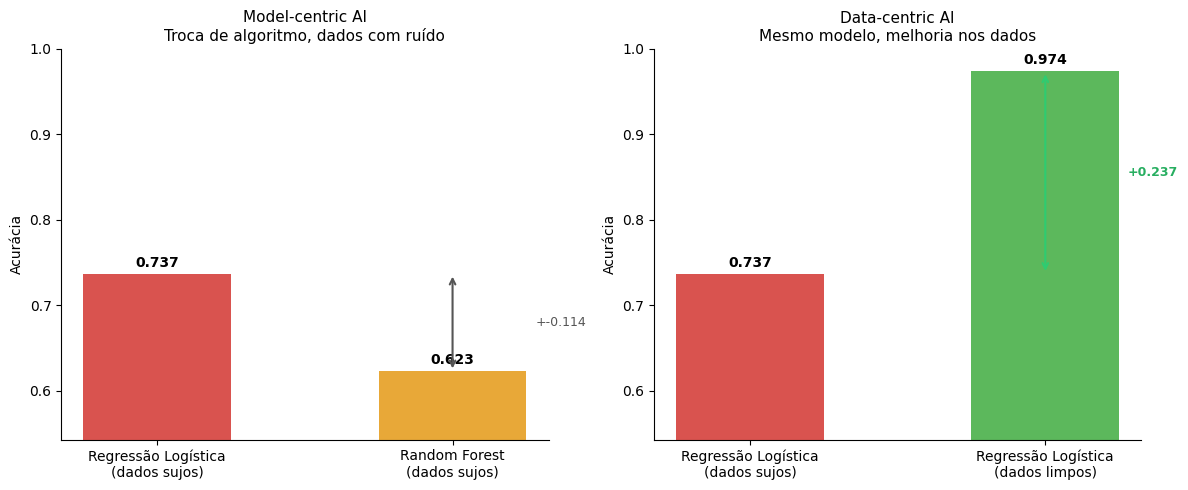

Ganho model-centric (LR → RF, dados sujos):   +-0.114
Ganho data-centric  (dados sujos → limpos):   +0.237


In [3]:
def avaliar_modelo(X_treino, X_teste, y_treino, y_teste, modelo):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_treino)
    X_ts = scaler.transform(X_teste)
    modelo.fit(X_tr, y_treino)
    return accuracy_score(y_teste, modelo.predict(X_ts))

X_tr_sujo, X_ts_sujo, y_tr, y_ts = train_test_split(X_sujo, y, test_size=0.2, random_state=42)
X_tr_limpo, X_ts_limpo, _, _     = train_test_split(X,     y, test_size=0.2, random_state=42)

# --- Abordagem Model-centric: troca de modelo, dados sujos ---
acc_lr_sujo  = avaliar_modelo(X_tr_sujo,  X_ts_sujo,  y_tr, y_ts, LogisticRegression(max_iter=1000, random_state=42))
acc_rf_sujo  = avaliar_modelo(X_tr_sujo,  X_ts_sujo,  y_tr, y_ts, RandomForestClassifier(n_estimators=100, random_state=42))

# --- Abordagem Data-centric: modelo simples, dados limpos ---
acc_lr_limpo = avaliar_modelo(X_tr_limpo, X_ts_limpo, y_tr, y_ts, LogisticRegression(max_iter=1000, random_state=42))

# ylim dinâmico: garante que todas as barras fiquem visíveis com padding adequado
todos_valores = [acc_lr_sujo, acc_rf_sujo, acc_lr_limpo]
ylim_bottom   = max(0.0, min(todos_valores) - 0.08)
ylim_top      = min(1.0, max(todos_valores) + 0.05)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Gráfico 1: Model-centric ──────────────────────────────────────────────────
rotulos_mc = ['Regressão Logística\n(dados sujos)', 'Random Forest\n(dados sujos)']
valores_mc = [acc_lr_sujo, acc_rf_sujo]
bars0 = axes[0].bar(rotulos_mc, valores_mc, color=['#d9534f', '#e8a838'], width=0.5)
axes[0].set_ylim(ylim_bottom, ylim_top)
axes[0].set_title('Model-centric AI\nTroca de algoritmo, dados com ruído', fontsize=11)
axes[0].set_ylabel('Acurácia')
for bar, v in zip(bars0, valores_mc):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
# Seta mostrando ganho (model-centric)
ganho_mc = acc_rf_sujo - acc_lr_sujo
axes[0].annotate('', xy=(1, acc_rf_sujo), xytext=(1, acc_lr_sujo),
                 arrowprops=dict(arrowstyle='<->', color='#555', lw=1.5))
axes[0].text(1.28, (acc_lr_sujo + acc_rf_sujo) / 2,
             f'+{ganho_mc:.3f}', va='center', fontsize=9, color='#555')

# ── Gráfico 2: Data-centric ───────────────────────────────────────────────────
rotulos_dc = ['Regressão Logística\n(dados sujos)', 'Regressão Logística\n(dados limpos)']
valores_dc = [acc_lr_sujo, acc_lr_limpo]
bars1 = axes[1].bar(rotulos_dc, valores_dc, color=['#d9534f', '#5cb85c'], width=0.5)
axes[1].set_ylim(ylim_bottom, ylim_top)
axes[1].set_title('Data-centric AI\nMesmo modelo, melhoria nos dados', fontsize=11)
axes[1].set_ylabel('Acurácia')
for bar, v in zip(bars1, valores_dc):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
# Seta mostrando ganho (data-centric)
ganho_dc = acc_lr_limpo - acc_lr_sujo
axes[1].annotate('', xy=(1, acc_lr_limpo), xytext=(1, acc_lr_sujo),
                 arrowprops=dict(arrowstyle='<->', color='#2ecc71', lw=1.5))
axes[1].text(1.28, (acc_lr_sujo + acc_lr_limpo) / 2,
             f'+{ganho_dc:.3f}', va='center', fontsize=9, color='#27ae60', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_01_data_vs_model_centric.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Ganho model-centric (LR → RF, dados sujos):   +{ganho_mc:.3f}")
print(f"Ganho data-centric  (dados sujos → limpos):   +{ganho_dc:.3f}")
if ganho_mc > 0:
    print(f"Data-centric gerou {ganho_dc/ganho_mc:.1f}× mais ganho do que a troca de algoritmo.")

**Interpretação:** Neste experimento, melhorar a qualidade dos dados (data-centric) gerou um ganho de performance **substancialmente maior** do que trocar para um modelo mais sofisticado (model-centric) com os mesmos dados ruidosos — replicando o padrão observado por Ng (2021), onde a abordagem data-centric produziu ganhos até **8× maiores**.

Isso não significa que arquitetura não importa — mas evidencia que dados de baixa qualidade são um **teto** para qualquer modelo. Modelos sofisticados treinados em dados ruins produzem resultados ruins **com alta confiança**.

---
## 2. As Seis Dimensões de Qualidade de Dados

Zhou et al. (2024) analisaram 17 ferramentas de qualidade de dados para ML e organizaram a qualidade em **seis dimensões fundamentais**. Nenhuma pode ser avaliada isoladamente: um dataset com alta completude mas baixa acurácia nos rótulos é potencialmente mais prejudicial do que um dataset incompleto com rótulos corretos.

Os problemas de qualidade de dados se organizam nessas seis categorias. Entender cada uma é o primeiro passo para tratá-las sistematicamente.

In [4]:
# Dataset artificial que concentra os principais problemas de qualidade
df = pd.DataFrame({
    'id':        [1, 2, 3, 3, 4, 5, 6, 7, 8, 9, 10],
    'nome':      ['Ana', 'Bruno', 'Carlos', 'Carlos', 'Diana', 'Eduardo', 'Flávia', 'Gabriel', 'Helena', 'Igor', 'Julia'],
    'idade':     [25, -5, 30, 30, 150, 28, 35, None, 29, 31, 27],      # outliers e valor ausente
    'renda':     [3000, 4500, 2800, 2800, 9999999, 3200, None, 4100, 2950, 3800, 3100],  # outlier e ausente
    'genero':    ['F', 'M', 'M', 'M', 'F', 'M', 'Feminino', 'M', 'F', 'Masculino', 'F'],  # inconsistência
    'data_nasc': ['1999-03-15', '1992-07-22', '1994-11-08', '1994-11-08', '1874-01-01',   # data inválida
                  '1996-04-30', '1989-06-17', '1997-09-05', '1995-12-20', '1993-02-14', '1997-08-10'],
    'cidade':    ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Belo Horizonte',
                  'Curitiba', 'SP', 'Recife', 'Salvador', 'Fortaleza', 'Manaus', None],  # abreviação + ausente
})

print("Dataset com problemas de qualidade:")
df

Dataset com problemas de qualidade:


,id,nome,idade,renda,genero,data_nasc,cidade
0,1,Ana,25.0,3000.0,F,1999-03-15,São Paulo
1,2,Bruno,-5.0,4500.0,M,1992-07-22,Rio de Janeiro
2,3,Carlos,30.0,2800.0,M,1994-11-08,Belo Horizonte
3,3,Carlos,30.0,2800.0,M,1994-11-08,Belo Horizonte
4,4,Diana,150.0,9999999.0,F,1874-01-01,Curitiba
5,5,Eduardo,28.0,3200.0,M,1996-04-30,SP
6,6,Flávia,35.0,NaN,Feminino,1989-06-17,Recife
7,7,Gabriel,NaN,4100.0,M,1997-09-05,Salvador
8,8,Helena,29.0,2950.0,F,1995-12-20,Fortaleza
9,9,Igor,31.0,3800.0,Masculino,1993-02-14,Manaus


In [5]:
# Diagnóstico automático de cada categoria de problema
problemas = {}

# 1. Completude — valores ausentes
ausentes = df.isnull().sum()
problemas['Completude (valores ausentes)'] = ausentes[ausentes > 0].to_dict()

# 2. Unicidade — registros duplicados
duplicatas = df[df.duplicated(subset=['id'], keep=False)]
problemas['Unicidade (IDs duplicados)'] = duplicatas[['id', 'nome']].values.tolist()

# 3. Validade — valores fora do domínio
idade_invalida = df[(df['idade'] < 0) | (df['idade'] > 120)]['idade'].dropna()
problemas['Validade (idades fora do domínio [0,120])'] = idade_invalida.to_dict()

# 4. Consistência — variável com representações diferentes
generos_distintos = df['genero'].unique().tolist()
problemas['Consistência (representações distintas de gênero)'] = generos_distintos

# 5. Acurácia — outliers estatísticos (Z-score > 3)
renda_valida = df['renda'].dropna()
z_scores = np.abs((renda_valida - renda_valida.mean()) / renda_valida.std())
outliers_renda = renda_valida[z_scores > 3]
problemas['Acurácia (outliers de renda, |z| > 3)'] = outliers_renda.to_dict()

print("=== Diagnóstico de Qualidade de Dados ===")
for categoria, detalhe in problemas.items():
    print(f"\n[{categoria}]")
    print(f"  {detalhe}")

=== Diagnóstico de Qualidade de Dados ===

[Completude (valores ausentes)]
  {'idade': 1, 'renda': 1, 'cidade': 1}

[Unicidade (IDs duplicados)]
  [[3, 'Carlos'], [3, 'Carlos']]

[Validade (idades fora do domínio [0,120])]
  {1: -5.0, 4: 150.0}

[Consistência (representações distintas de gênero)]
  ['F', 'M', 'Feminino', 'Masculino']

[Acurácia (outliers de renda, |z| > 3)]
  {}


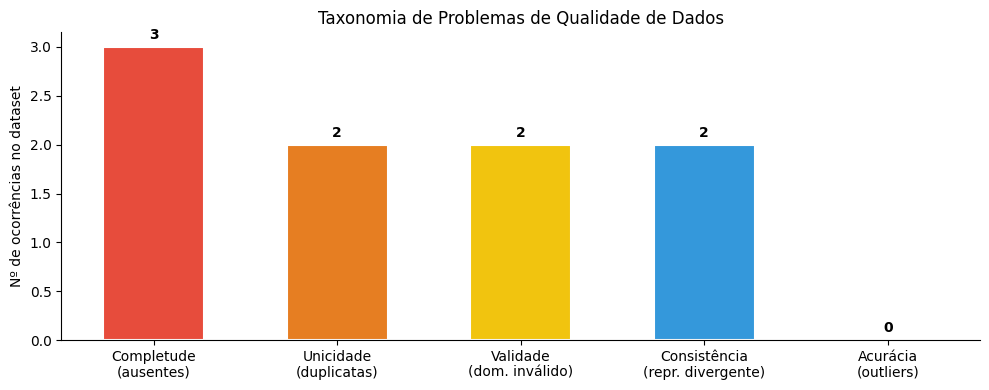

In [6]:
# Visualização da taxonomia de problemas
categorias = ['Completude\n(ausentes)', 'Unicidade\n(duplicatas)', 'Validade\n(dom. inválido)',
              'Consistência\n(repr. divergente)', 'Acurácia\n(outliers)']
contagens  = [
    int(ausentes.sum()),
    len(duplicatas),
    len(idade_invalida),
    len(set(generos_distintos)) - 2,  # 2 representações a mais além das 2 canônicas
    len(outliers_renda),
]
cores = ['#e74c3c', '#e67e22', '#f1c40f', '#3498db', '#9b59b6']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(categorias, contagens, color=cores, width=0.55, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Nº de ocorrências no dataset')
ax.set_title('Taxonomia de Problemas de Qualidade de Dados')
for bar, val in zip(bars, contagens):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05, str(val),
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_02_taxonomia_qualidade.png', dpi=150, bbox_inches='tight')
plt.show()

### Tabela-resumo das seis dimensões (Zhou et al., 2024)

| Dimensão | Pergunta central | Exemplo de problema |
|---|---|---|
| **Completude** | Os dados estão todos presentes? | Valores `NaN`, campos obrigatórios vazios |
| **Unicidade** | Existem registros duplicados? | Mesmo cliente cadastrado duas vezes |
| **Validade** | Os valores respeitam o domínio esperado? | Idade negativa, CEP com letras |
| **Consistência** | Os dados são internamente coerentes? | `"M"` e `"Masculino"` para o mesmo conceito |
| **Acurácia** | Os valores correspondem à realidade? | Renda de R$9.999.999 para pessoa física comum |
| **Atualidade** | Os dados são suficientemente recentes? | Features de meses atrás em um modelo de fraude |

<br>
> Em Zhou et al. (2024), os autores destacam que a avaliação sistemática das seis dimensões em conjunto é o que diferencia a **engenharia de dados profissional** da simples coleta de dados.

---
## 3. Data Cascades e Custos de Poor Data Quality em Produção

**Data cascades** são efeitos em cascata causados por dados de baixa qualidade que se propagam ao longo do pipeline de ML — desde a coleta até o modelo em produção.

O problema central é que decisões tomadas com dados ruins são difíceis de rastrear e corrigir depois.

### Simulação: degradação do modelo com corrupção crescente de dados

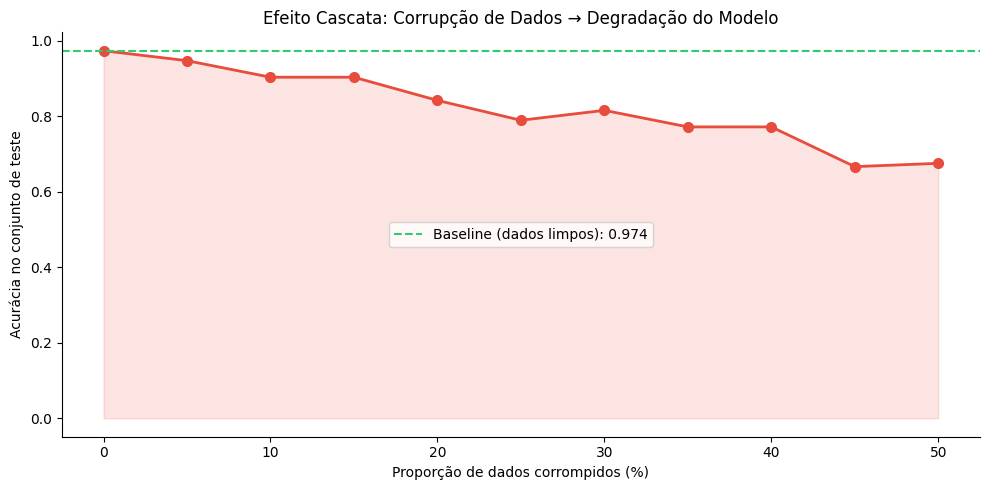

Acurácia por nível de corrupção:
     0% corrompido → acurácia: 0.974
     5% corrompido → acurácia: 0.947
    10% corrompido → acurácia: 0.904
    15% corrompido → acurácia: 0.904
    20% corrompido → acurácia: 0.842
    25% corrompido → acurácia: 0.789
    30% corrompido → acurácia: 0.816
    35% corrompido → acurácia: 0.772
    40% corrompido → acurácia: 0.772
    45% corrompido → acurácia: 0.667
    50% corrompido → acurácia: 0.675


In [7]:
# Simulação: como a proporção de dados corrompidos afeta o desempenho final do modelo
data = load_breast_cancer()
X_original, y = data.data, data.target

proporcoes_corrupcao = np.arange(0, 0.55, 0.05)  # de 0% a 50%
acuracias = []

for proporcao in proporcoes_corrupcao:
    X_corrompido = X_original.copy().astype(float)
    n = int(len(X_corrompido) * proporcao)
    if n > 0:
        indices = np.random.choice(len(X_corrompido), n, replace=False)
        # Simula três tipos de corrupção: ruído, ausente, inversão de label
        idx_ruido    = indices[:n//3]
        idx_ausente  = indices[n//3: 2*n//3]
        idx_label    = indices[2*n//3:]
        X_corrompido[idx_ruido]   += np.random.normal(0, X_corrompido.std(axis=0) * 4, X_corrompido[idx_ruido].shape)
        X_corrompido[idx_ausente] = np.nanmedian(X_corrompido, axis=0)  # imputa com mediana
        y_corrompido = y.copy()
        y_corrompido[idx_label] = 1 - y_corrompido[idx_label]           # inverte o label
    else:
        y_corrompido = y.copy()

    X_tr, X_ts, y_tr, y_ts = train_test_split(X_corrompido, y_corrompido, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    modelo = LogisticRegression(max_iter=1000, random_state=42)
    modelo.fit(scaler.fit_transform(X_tr), y_tr)
    acuracias.append(accuracy_score(y_ts, modelo.predict(scaler.transform(X_ts))))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(proporcoes_corrupcao * 100, acuracias, marker='o', color='#e74c3c', linewidth=2, markersize=7)
ax.fill_between(proporcoes_corrupcao * 100, acuracias, alpha=0.15, color='#e74c3c')
ax.axhline(acuracias[0], color='#2ecc71', linestyle='--', linewidth=1.5, label=f'Baseline (dados limpos): {acuracias[0]:.3f}')
ax.set_xlabel('Proporção de dados corrompidos (%)')
ax.set_ylabel('Acurácia no conjunto de teste')
ax.set_title('Efeito Cascata: Corrupção de Dados → Degradação do Modelo')
ax.legend()
plt.tight_layout()
plt.savefig('fig_03_data_cascade.png', dpi=150, bbox_inches='tight')
plt.show()

print("Acurácia por nível de corrupção:")
for p, a in zip(proporcoes_corrupcao, acuracias):
    print(f"  {p*100:4.0f}% corrompido → acurácia: {a:.3f}")


---
## Referências

- Zhou, Y. et al. (2024). *A Survey on Data Quality Dimensions and Tools for Machine Learning*. IEEE AITest. https://arxiv.org/abs/2406.19614  
- Sambasivan, N. et al. (2021). *"Everyone wants to do the model work, not the data work"*. ACM CHI 2021. DOI: 10.1145/3411764.3445518  
- Ng, A. (2021). *MLOps: From Model-centric to Data-centric AI*. Landing AI. https://landing.ai/data-centric-ai/  
- Buolamwini, J. & Gebru, T. (2018). *Gender Shades: Intersectional Accuracy Disparities in Commercial Gender Classification*. FAT* 2018. PMLR 81:1–15.  
- NIST (2023). *Artificial Intelligence Risk Management Framework (AI RMF 1.0)*. NIST AI 100-1. DOI: 10.6028/NIST.AI.100-1  
- Gartner (2020). *Data Quality: Best Practices for Accurate Insights*. https://www.gartner.com/en/data-analytics/topics/data-quality  
- Wang, R. Y. & Strong, D. M. (1996). *Beyond Accuracy: What Data Quality Means to Data Consumers*. Journal of MIS, 12(4).